<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/AIML_CNN_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install tensorflow opencv-python

In [2]:
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
import seaborn as sns
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ReduceLROnPlateau

In [3]:
import os
import json

# 1. Set your Kaggle API Token as an environment variable
# Replace 'your_kaggle_api_token' with your actual token.
# You can get this from your Kaggle account settings.
%env KAGGLE_API_TOKEN='your_kaggle_api_token'

# 2. Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# 3. Define the path for the kaggle.json file
kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')

# 4. Get the API token from the environment variable
kaggle_api_token = os.environ.get('KAGGLE_API_TOKEN')

# 5. Write the API token and your username to kaggle.json
# Replace 'your_kaggle_username' with your actual Kaggle username.
if kaggle_api_token and kaggle_api_token != 'your_kaggle_api_token':
    with open(kaggle_json_path, 'w') as f:
        json.dump({'username': 'varsha chikane', 'key': 'KGAT_29343850a3340506afd42e94c7155cea'}, f)
    # 6. Set the correct permissions for kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json
    print("kaggle.json created and permissions set successfully.")
else:
    print("KAGGLE_API_TOKEN environment variable not found or still set to placeholder. Please ensure it's set with your actual token.")


env: KAGGLE_API_TOKEN='your_kaggle_api_token'
kaggle.json created and permissions set successfully.


In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [5]:
labels = ['PNEUMONIA', 'NORMAL']
image_size = 150

def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            try:
                image_path = os.path.join(path, img)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # Load as grayscale

                # Check if image was loaded successfully; if not, skip to the next image
                if image is None:
                    print(f"Warning: Could not read image {image_path}. Skipping.")
                    continue

                resized_array = cv2.resize(image, (image_size, image_size))
                data.append([resized_array, class_num])
            except Exception as e:
                print(f"Error processing {image_path}: {e}")
    return np.array(data, dtype=object)

In [6]:
import os # Added to ensure 'os' is defined
import numpy as np # Added for robustness, as np.array is used

train = get_training_data('/content/chest_xray/train')

x = []
y = []

for image,label in train:
    x.append(image)
    y.append(label)

x = np.array(x).reshape(-1, image_size, image_size, 1)
y = np.array(y)

In [7]:
train = get_training_data('/content/chest_xray/train')
test = get_training_data('/content/chest_xray/test')
val = get_training_data('/content/chest_xray/val')

<Axes: xlabel='count'>

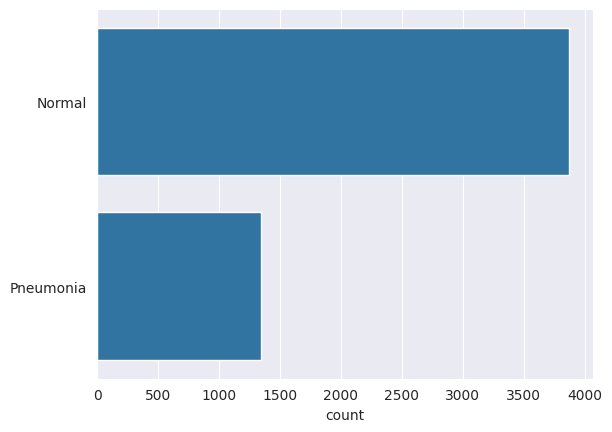

In [8]:
l = []
for i in train:
  if(i[1] == 0):
    l.append('Normal')
  else:
    l.append('Pneumonia')
sns.set_style('darkgrid')
sns.countplot(l)

Text(0.5, 1.0, 'NORMAL')

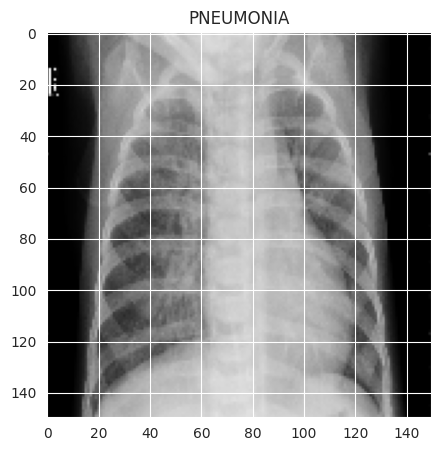

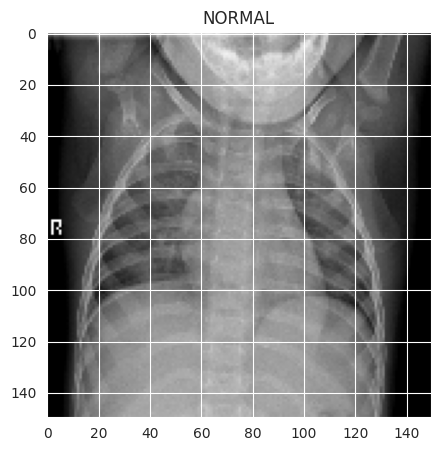

In [9]:
plt.figure(figsize = (5,5))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])


plt.figure(figsize = (5,5))
plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-1][1]])

In [10]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

In [11]:
x_train = np.array(x_train) / 255
x_val = np.array(x_val) / 255
x_test = np.array(x_test) / 255

In [12]:
x_train = x_train.reshape(-1, image_size, image_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, image_size, image_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, image_size, image_size, 1)
y_test = np.array(y_test)

In [13]:
print(f"Length of x_train: {len(x_train)}")
print(f"Length of y_train: {len(y_train)}")

if len(x_train) == len(y_train):
    print("x_train and y_train have consistent lengths. You can proceed with model training.")
else:
    print("Error: x_train and y_train still have inconsistent lengths. Please re-check data preparation steps.")

Length of x_train: 5216
Length of y_train: 5216
x_train and y_train have consistent lengths. You can proceed with model training.


In [14]:
datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range=10,
        zoom_range = 0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=False,
        vertical_flip=False)

datagen.fit(x_train)

In [15]:
from keras.layers import BatchNormalization # Added BatchNormalization import

model = Sequential()

model.add(Conv2D(32, (3, 3), strides = 1, padding = 'same', activation = 'relu', input_shape = (150, 150, 1))) # Changed input_shape to 1 channel
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2), strides = 2, padding = 'same'))

model.add(Conv2D(64, (3, 3), strides = 1, padding = 'same', activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2), strides = 2, padding = 'same'))
model.add(Conv2D(64, (3, 3), strides = 1, padding = 'same', activation = 'relu')) # Fixed typo from mpdel
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2), strides = 2, padding = 'same'))
model.add(Conv2D(128, (3, 3), strides = 1, padding = 'same', activation = 'relu')) # Fixed typo from mpdel
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2), strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(units = 128, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1, activation = 'sigmoid'))
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,769,409 (6.75 MB)

 Trainable params: 1,768,833 (6.75 MB)

 Non-trainable params: 576 (2.25 KB)

In [17]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=2, verbose=1, factor=0.3, min_lr=0.000001)

history = model.fit(datagen.flow(x_train, y_train, batch_size=32),
                    epochs = 15,
                    validation_data = (x_val, y_val),
                    callbacks = [learning_rate_reduction])

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.8752 - loss: 0.3623 - val_accuracy: 0.5000 - val_loss: 16.0636 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9354 - loss: 0.1761 - val_accuracy: 0.5000 - val_loss: 22.1078 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9536 - loss: 0.1345
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9500 - loss: 0.1441 - val_accuracy: 0.5000 - val_loss: 12.7887 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9530 - loss: 0.1223 - val_accuracy: 0.6250 - val_loss: 1.0576 - learning_rate: 3.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.9636 - loss: 0.1125 - val_accuracy: 0.5625 - val_loss: 1.0335 - learning_rate: 3.0000e-04
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.

In [29]:
print("Loss of the Model is -", model.evaluate(x_test, y_test)[0])
print("Accuracy of the Model is -", model.evaluate(x_test, y_test)[1]*100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9135 - loss: 0.3107
Loss of the Model is - 0.31065115332603455
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9135 - loss: 0.3107
Accuracy of the Model is - 91.34615659713745 %


Analysis After Model Training

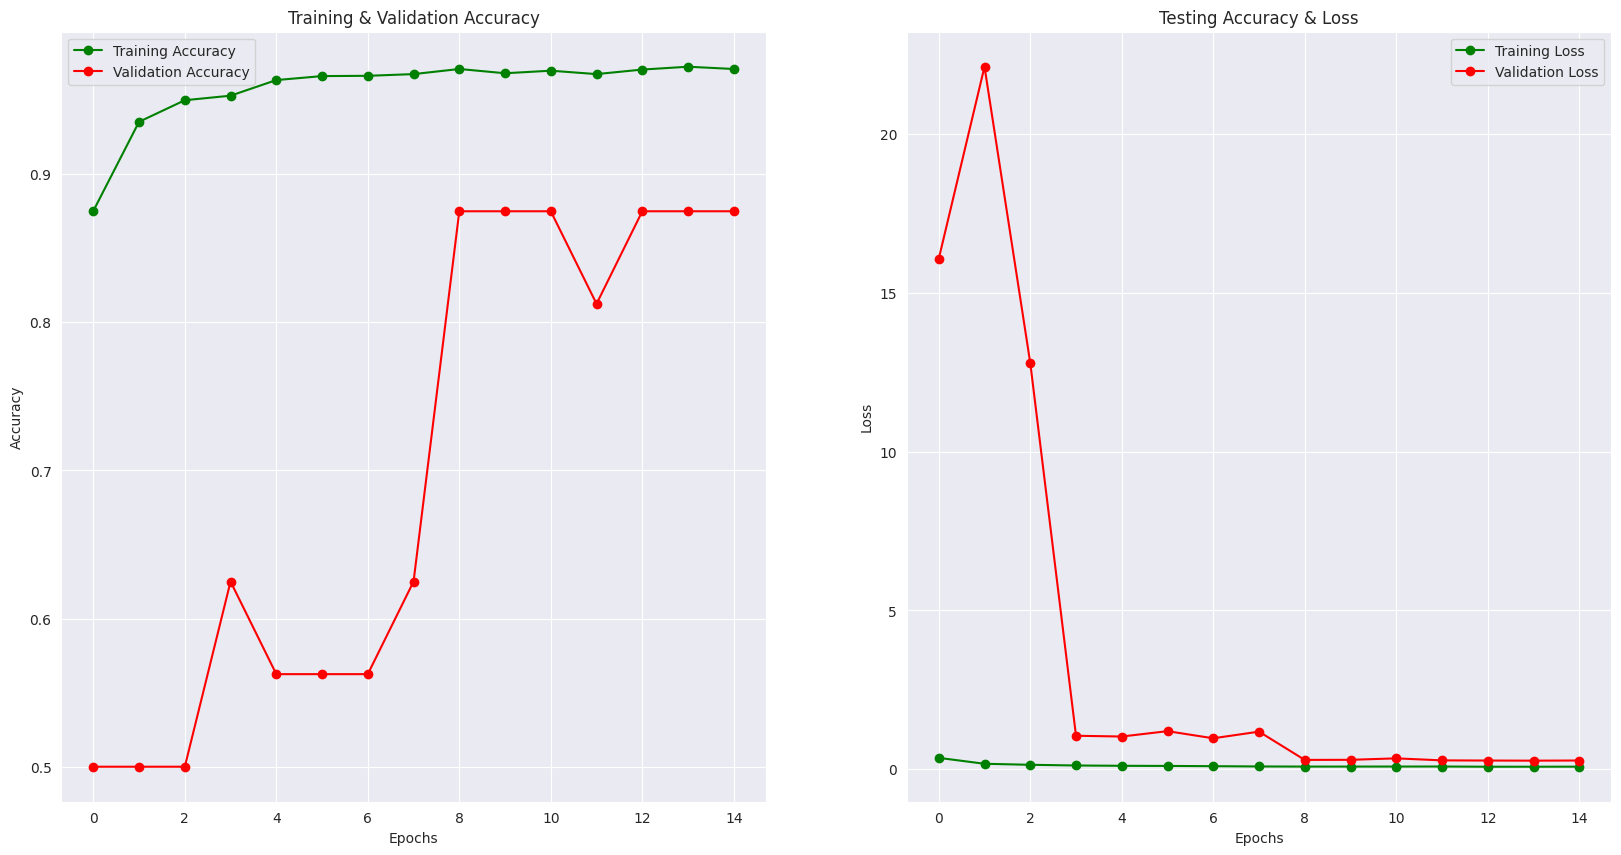

In [19]:
epochs = [i for i in range(len(history.history['accuracy']))]
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label = 'Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(epochs, train_loss, 'g-o', label = 'Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.show()

In [21]:
predictions = model.predict(x_test)
predictions = (predictions > 0.5).astype(int).reshape(1,-1)[0]
predictions[:33]
print(classification_report(y_test, predictions, target_names = ['Pneumonia(Class 0)', 'Normal(Class 1)']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
                    precision    recall  f1-score   support

Pneumonia(Class 0)       0.90      0.97      0.93       390
   Normal(Class 1)       0.95      0.81      0.88       234

          accuracy                           0.91       624
         macro avg       0.92      0.89      0.90       624
      weighted avg       0.92      0.91      0.91       624



In [22]:
cm = confusion_matrix(y_test, predictions)
cm

array([[380,  10],
       [ 44, 190]])

In [23]:
cm = pd.DataFrame(cm, index = [' 0', '1'], columns = ['0', '1'])

<Axes: >

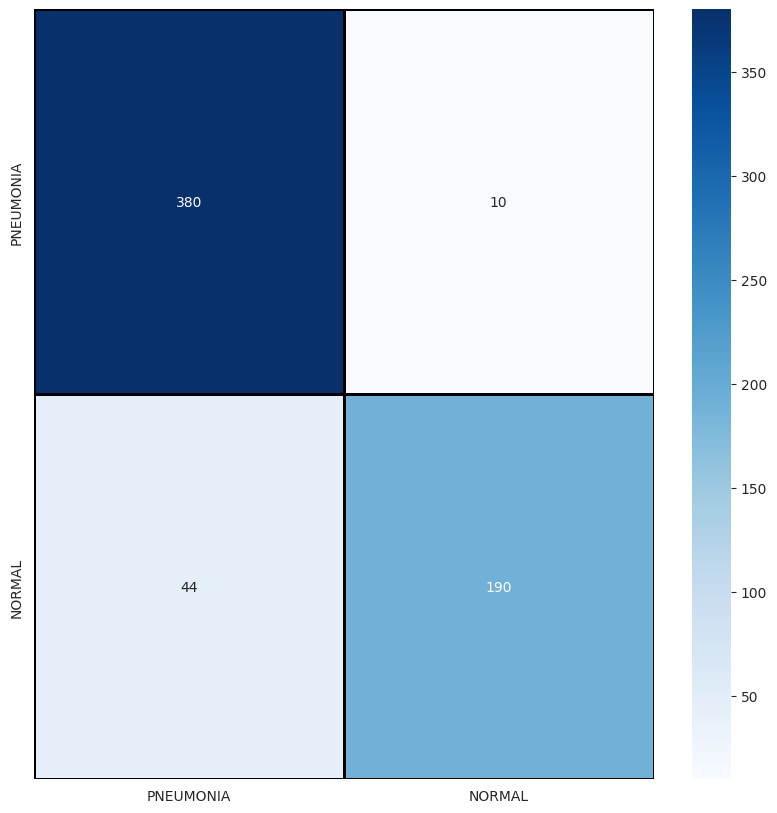

In [24]:
plt.figure(figsize = (10,10))
sns.heatmap(cm, cmap = 'Blues', linecolor = 'black', linewidth = 1, annot = True, fmt = '', xticklabels = labels, yticklabels = labels)

In [25]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

Some of the Correctly predicted calasses

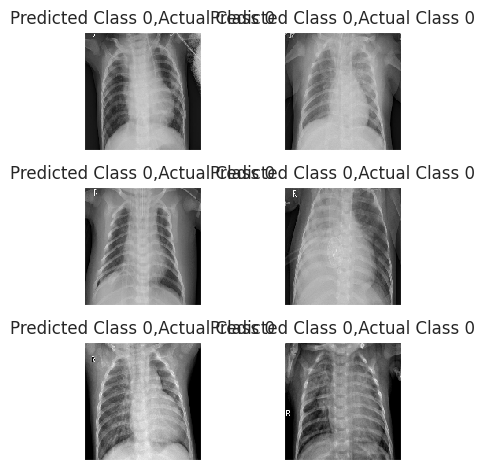

In [27]:
i = 0
for c in correct[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150, 150), cmap = 'gray', interpolation = 'none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

Some of the Incorrectly Predicted data

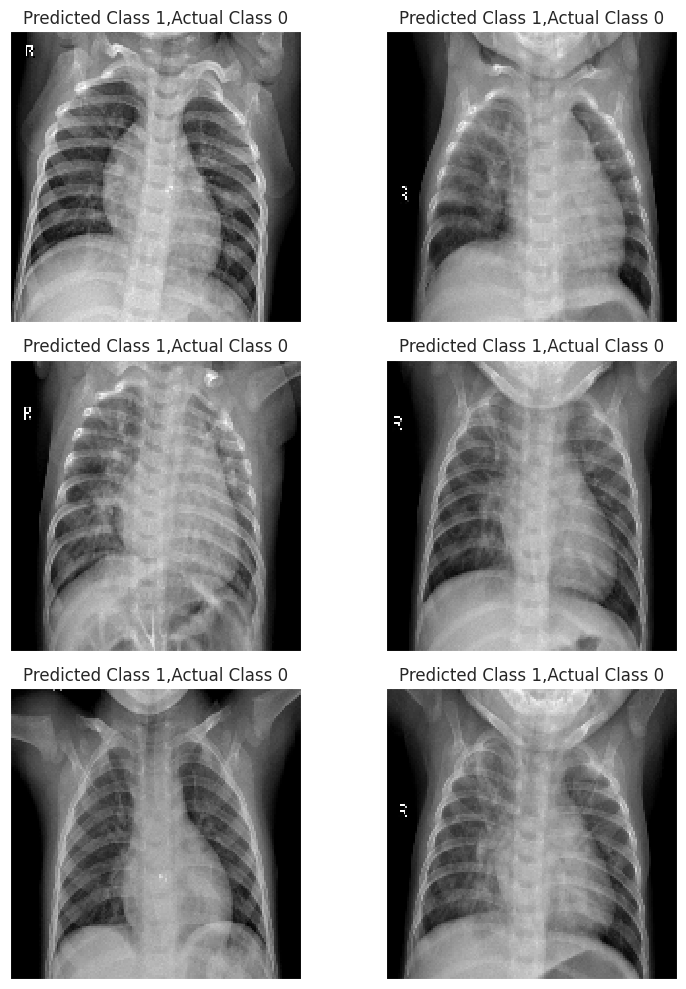

In [28]:
plt.figure(figsize = (10,10))
i = 0
for c in incorrect[:6]:
    plt.subplot(3,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150, 150), cmap = 'gray', interpolation = 'none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1